# 06 — N=8 Kuramoto benchmark with measurement noise: new Step-3 framework

This notebook re-runs the canonical noisy \(N=8\) temporal Kuramoto benchmark through the **new TIDES Step 3**.

The upstream experiment is intentionally kept the same as Notebook 05:

\[
x_{\rm clean}(t)
\rightarrow x_{\rm obs}(t)
\rightarrow \text{Step 1}
\rightarrow \text{stage-local smoothing}
\rightarrow \varepsilon
\rightarrow \mathcal B_\varepsilon .
\]

The new physical-inference layer is

\[
\mathcal B_\varepsilon
\rightarrow
\underbrace{\text{in1}}_{\text{weight-category representation}}
\leftrightarrow
\underbrace{\text{in2}}_{\text{reversible support exploration}}
\rightarrow
\underbrace{\text{in3}}_{\text{free-}W\text{ basin compression}}
\rightarrow
\text{terminal in1 re-profiling}.
\]

For this regression we test the validated two-atom dynamics support

\[
J_2=(0,2),
\qquad
\phi(z)=z+\alpha z^3,
\]

inside the degree-11 relative-polynomial library.

A frozen **broad \(E=47\) structural seed** from the preceding Step-3 development benchmark is embedded below. It is used only to isolate and validate the new in1/in2/in3 framework; it is not constructed from planted truth in this notebook. Because that broad seed has already passed the reversible-support audit, in2 is given an explicit benchmark-only coverage certificate and makes no replacement move. The scientific test here is whether the new physical profiling, new discrete description length, and category-relaxed basin compression reproduce the \(E47\to E30\) topology result under the same measurement noise.

No `mdl_search.py`, `mdl_precision.py`, or `step3_physical_compression.py` code is used.

In [1]:
# ============================================================
# Cell 1 — imports and active-code audit
# ============================================================
from pathlib import Path
from itertools import combinations
import sys
import time
import math
import importlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

HERE = Path.cwd()
CODE_DIR = None

for candidate in (
    HERE,
    HERE / "tides_joint",
    HERE / "tides_new",
    HERE.parent,
    Path("/mnt/data"),
):
    if (candidate / "tides.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not find tides.py. Put this notebook in the same directory as "
        "the current TIDES source files, or run it from their parent directory."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import trajectory_smoothing as tsmooth
import pairwise_local_interaction_library as plib
import edge_space_operators as edgeops
import structural_linear_cache as slcache
import step2_edge_space_reconstruction as step2core
import step3func_physical_profiling as physprof
import mdl_description_length as mdld
import step3in1_weight_category_distribution as in1
import step3in2_structural_support_exploration as in2
import step3in3_basin_preserving_compression as in3
import step3_physical_inference as step3
import tides

for module in (
    tsmooth, plib, edgeops, slcache, step2core,
    physprof, mdld, in1, in2, in3, step3, tides,
):
    importlib.reload(module)

print("TIDES loaded from:")
print(tides.__file__)
print("\nNew Step 3 loaded from:")
print(step3.__file__)
print("\nShared physical profiling loaded from:")
print(physprof.__file__)
print("\nDiscrete DL loaded from:")
print(mdld.__file__)

for retired in ("mdl_search", "mdl_precision", "step3_physical_compression"):
    assert retired not in sys.modules, f"Retired module unexpectedly loaded: {retired}"

assert hasattr(in1, "PhysicalCategoryComputation")
assert hasattr(physprof, "profile_free_weights_and_dynamics")
assert hasattr(mdld, "compute_representation_description_length")

TIDES loaded from:
/mnt/data/tides.py

New Step 3 loaded from:
/mnt/data/step3_physical_inference.py

Shared physical profiling loaded from:
/mnt/data/step3func_physical_profiling.py

Discrete DL loaded from:
/mnt/data/mdl_description_length.py


In [2]:
# ============================================================
# Cell 2 — Kuramoto N=8 planted truth
# Same generator as the previous N=8 benchmark.
# ============================================================
SEED = 20260811
N = 8
DT = 5.0e-4
STAGE_DURATION = 0.060
N_STAGES = 6
INTERVALS_PER_STAGE = int(round(STAGE_DURATION / DT))
assert INTERVALS_PER_STAGE == 120

CANDIDATE_EDGES = tuple(combinations(range(1, N + 1), 2))
EDGE_INDEX_1B = {edge: m for m, edge in enumerate(CANDIDATE_EDGES)}
assert len(CANDIDATE_EDGES) == 28

weight_rng = np.random.default_rng(SEED)
EDGE_WEIGHT = {
    edge: int(weight_rng.integers(800, 1201)) / 1000.0
    for edge in CANDIDATE_EDGES
}

SNAPSHOTS = (
    ((1, 3), (2, 5), (2, 8), (3, 5), (3, 8),
     (4, 6), (4, 7), (5, 6), (6, 8), (7, 8)),
    ((1, 3), (1, 5), (2, 3), (2, 8), (3, 5),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 3), (2, 7), (2, 8),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 4), (1, 6), (2, 7), (2, 8),
     (3, 8), (4, 5), (4, 6), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 7), (2, 8), (3, 8),
     (4, 5), (5, 6), (5, 7), (6, 7), (7, 8)),
    ((1, 3), (1, 8), (2, 8), (3, 8), (4, 5),
     (4, 8), (5, 6), (5, 7), (6, 7), (7, 8)),
)

X0 = np.array([
    -0.319989, -0.301418, 0.354093, -0.213312,
    -0.026615,  0.067347, 0.282008,  0.157887,
], dtype=float)
X0 -= X0.mean()


def edge_field(x, edge):
    i, j = edge
    i -= 1
    j -= 1
    q = EDGE_WEIGHT[edge] * np.sin(x[j] - x[i])
    out = np.zeros_like(x, dtype=float)
    out[i] += q
    out[j] -= q
    return out


def stage_field(x, stage):
    out = np.zeros(N, dtype=float)
    for edge in SNAPSHOTS[stage]:
        out += edge_field(x, edge)
    return out


def rk4_step(x, dt, stage):
    k1 = stage_field(x, stage)
    k2 = stage_field(x + 0.5 * dt * k1, stage)
    k3 = stage_field(x + 0.5 * dt * k2, stage)
    k4 = stage_field(x + dt * k3, stage)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def is_connected(edge_set):
    adjacency = {i: set() for i in range(1, N + 1)}
    for i, j in edge_set:
        adjacency[i].add(j)
        adjacency[j].add(i)
    seen, stack = {1}, [1]
    while stack:
        u = stack.pop()
        for v in adjacency[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == N


transition_supports_true = []
for k in range(N_STAGES - 1):
    before = set(SNAPSHOTS[k])
    after = set(SNAPSHOTS[k + 1])
    transition_supports_true.append(tuple(sorted(before ^ after)))

assert all(len(snapshot) == 10 for snapshot in SNAPSHOTS)
assert all(is_connected(snapshot) for snapshot in SNAPSHOTS)
assert all(len(S) == 4 for S in transition_supports_true)

true_change_times = np.arange(1, N_STAGES) * STAGE_DURATION
true_transition_indices = np.rint(true_change_times / DT).astype(int)

print("=" * 90)
print("N=8 Kuramoto benchmark truth")
print("=" * 90)
print("candidate edges M       :", len(CANDIDATE_EDGES))
print("active edges / stage    :", [len(G) for G in SNAPSHOTS])
print("true edge law           : sin(x_neighbor - x_self)")
print("true change times       :", true_change_times)
print("true transition indices :", true_transition_indices)
for k, S in enumerate(transition_supports_true, 1):
    print(f"transition {k}: {S}")

N=8 Kuramoto benchmark truth
candidate edges M       : 28
active edges / stage    : [10, 10, 10, 10, 10, 10]
true edge law           : sin(x_neighbor - x_self)
true change times       : [0.06 0.12 0.18 0.24 0.3 ]
true transition indices : [120 240 360 480 600]
transition 1: ((1, 5), (2, 3), (2, 5), (6, 8))
transition 2: ((1, 5), (1, 6), (2, 7), (3, 5))
transition 3: ((1, 4), (2, 3), (4, 5), (4, 7))
transition 4: ((1, 4), (4, 6), (5, 7), (6, 7))
transition 5: ((1, 6), (1, 8), (2, 7), (4, 8))


Kuramoto trajectory generated
X shape                : (721, 8)
||X(T)-X(0)||          : 4.527580e-01
max |x_i(t)|           : 3.540929e-01
sum_i x_i change       : -3.608225e-16
all finite             : True


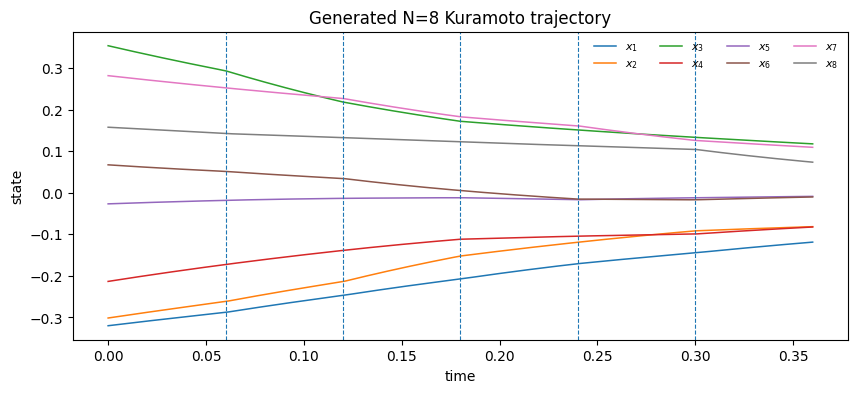

In [3]:
# ============================================================
# Cell 3 — Generate trajectory
# ============================================================
n_total_intervals = N_STAGES * INTERVALS_PER_STAGE
T = np.arange(n_total_intervals + 1, dtype=float) * DT
X = np.empty((n_total_intervals + 1, N), dtype=float)
X[0] = X0

true_stage_of_interval = np.repeat(
    np.arange(N_STAGES, dtype=int), INTERVALS_PER_STAGE
)
for n, stage in enumerate(true_stage_of_interval):
    X[n + 1] = rk4_step(X[n], DT, int(stage))

t = T.copy()

state_displacement = np.linalg.norm(X[-1] - X[0])
max_abs_state = np.max(np.abs(X))
net_sum_change = float(X[-1].sum() - X[0].sum())

print("=" * 90)
print("Kuramoto trajectory generated")
print("=" * 90)
print("X shape                :", X.shape)
print("||X(T)-X(0)||          :", f"{state_displacement:.6e}")
print("max |x_i(t)|           :", f"{max_abs_state:.6e}")
print("sum_i x_i change       :", f"{net_sum_change:.6e}")
print("all finite             :", np.isfinite(X).all())

assert X.shape == (721, 8)
assert np.allclose(np.diff(t), DT)
assert np.isfinite(X).all()
assert abs(net_sum_change) < 1e-10

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Generated N=8 Kuramoto trajectory")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()

In [4]:
# ============================================================
# Measurement-noise control
# MEASUREMENT_NOISE_REL = 0.0 disables noise; smoothing still differs from Notebook 04.
#
# Noise model:
#     X_obs = X_clean + sigma_m * xi,
#     xi ~ N(0,1) iid,
#     sigma_m = MEASUREMENT_NOISE_REL * RMS(X_clean).
#
# X_CLEAN is retained for validation.  Downstream cells continue
# to use observed X; preprocessing below jointly smooths states and derivatives.
# ============================================================

# Report recovery under noise without stopping at a truth mismatch.
# Set True only when intentionally running strict truth-recovery checks.
STRICT_TRUTH_CHECKS = False

MEASUREMENT_NOISE_SEED = 20260917
# MEASUREMENT_NOISE_REL = 0.0
MEASUREMENT_NOISE_REL = 1e-4

X_CLEAN = X.copy()
X_RMS = float(np.sqrt(np.mean(X_CLEAN**2)))
SIGMA_MEASUREMENT = float(MEASUREMENT_NOISE_REL * X_RMS)

measurement_noise_rng = np.random.default_rng(MEASUREMENT_NOISE_SEED)
MEASUREMENT_NOISE = (
    SIGMA_MEASUREMENT
    * measurement_noise_rng.standard_normal(X_CLEAN.shape)
)

X = X_CLEAN + MEASUREMENT_NOISE

print("=" * 90)
print("MEASUREMENT NOISE")
print("=" * 90)
print("relative noise level sigma_m / RMS(X) :", f"{MEASUREMENT_NOISE_REL:.12e}")
print("clean trajectory RMS                 :", f"{X_RMS:.12e}")
print("measurement-noise sigma              :", f"{SIGMA_MEASUREMENT:.12e}")
print("realized noise RMS                    :", f"{np.sqrt(np.mean(MEASUREMENT_NOISE**2)):.12e}")
print("max |measurement noise|               :", f"{np.max(np.abs(MEASUREMENT_NOISE)):.12e}")
print("noise disabled                        :", bool(MEASUREMENT_NOISE_REL == 0.0))

if MEASUREMENT_NOISE_REL == 0.0:
    assert np.array_equal(X, X_CLEAN)

MEASUREMENT NOISE
relative noise level sigma_m / RMS(X) : 1.000000000000e-04
clean trajectory RMS                 : 1.587733939907e-01
measurement-noise sigma              : 1.587733939907e-05
realized noise RMS                    : 1.579343984850e-05
max |measurement noise|               : 6.171401023940e-05
noise disabled                        : False


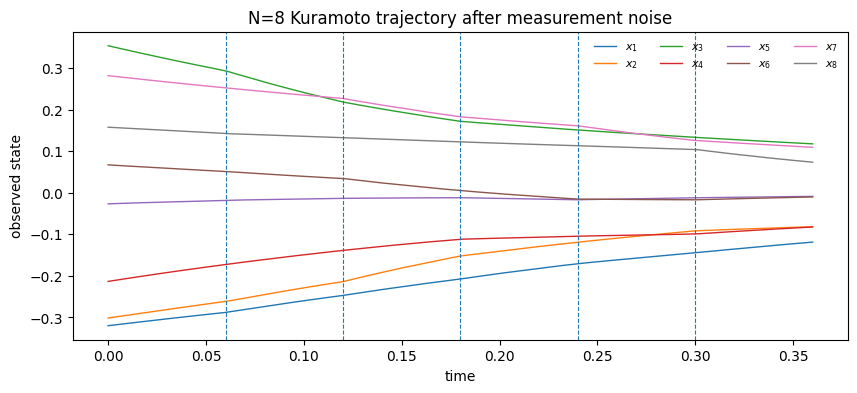

In [5]:
# ============================================================
# Cell 5 — observed noisy trajectory
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.0, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("observed state")
ax.set_title("N=8 Kuramoto trajectory after measurement noise")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()

STEP 1 — blind temporal segmentation
window size        : 5
window duration    : 2.500000e-03
MAD multiplier     : 8.0
jump median        : 4.604364322778e-02
jump MAD           : 8.127564288887e-03
robust scale       : 1.204992681470e-02
blind threshold    : 1.424430577454e-01
true indices       : [120 240 360 480 600]
detected indices   : [120 240 360 480 600]
detected times     : [0.06 0.12 0.18 0.24 0.3 ]
exact recovery     : True


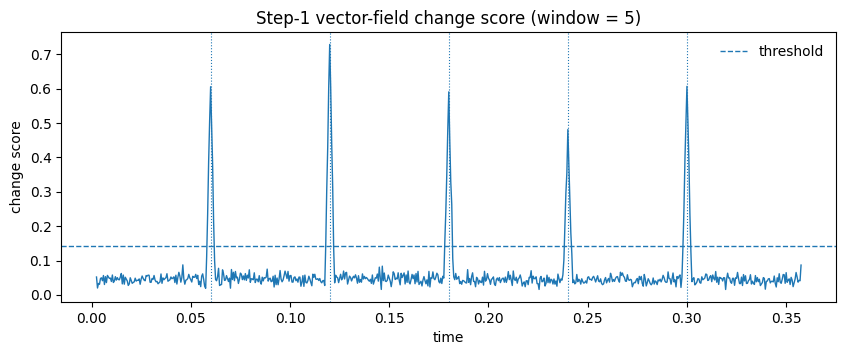

In [6]:
# ============================================================
# Cell 4 — Candidate-edge incidence + blind Step 1
# Window-averaged change detection
# ============================================================

M = len(CANDIDATE_EDGES)
D = np.zeros((N, M), dtype=float)

for m, (i, j) in enumerate(CANDIDATE_EDGES):
    D[i - 1, m] = -1.0
    D[j - 1, m] = +1.0


# ------------------------------------------------------------
# Step-1 controls
# ------------------------------------------------------------

STEP1_WINDOW = 5
STEP1_MAD_MULTIPLIER = 8.0


# ------------------------------------------------------------
# Blind change-point detection
# threshold=None lets detect_changes use its internal
# robust MAD threshold.
# ------------------------------------------------------------

s1_check = tides.detect_changes(
    X,
    t,
    method="window",
    window=STEP1_WINDOW,
    threshold=None,
    mad_multiplier=STEP1_MAD_MULTIPLIER,
    min_separation=1,
)


# ------------------------------------------------------------
# Recover the threshold value for diagnostics / plotting
# ------------------------------------------------------------

jump = s1_check.scores

jump_median = float(np.median(jump))
jump_mad = float(np.median(np.abs(jump - jump_median)))
jump_robust_scale = 1.4826 * jump_mad

blind_threshold = (
    jump_median
    + STEP1_MAD_MULTIPLIER * jump_robust_scale
)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print("=" * 90)
print("STEP 1 — blind temporal segmentation")
print("=" * 90)

print("window size        :", STEP1_WINDOW)
print("window duration    :", f"{STEP1_WINDOW * DT:.6e}")
print("MAD multiplier     :", STEP1_MAD_MULTIPLIER)
print("jump median        :", f"{jump_median:.12e}")
print("jump MAD           :", f"{jump_mad:.12e}")
print("robust scale       :", f"{jump_robust_scale:.12e}")
print("blind threshold    :", f"{blind_threshold:.12e}")
print("true indices       :", true_transition_indices)
print("detected indices   :", s1_check.transition_indices)
print("detected times     :", s1_check.transition_times)

step1_exact = np.array_equal(
    s1_check.transition_indices,
    true_transition_indices,
)

print("exact recovery     :", step1_exact)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(
    s1_check.score_times,
    s1_check.scores,
    lw=1.0,
)

ax.axhline(
    blind_threshold,
    ls="--",
    lw=1.0,
    label="threshold",
)

for tc in true_change_times:
    ax.axvline(
        tc,
        ls=":",
        lw=0.8,
    )

ax.set_xlabel("time")
ax.set_ylabel("change score")
ax.set_title(
    f"Step-1 vector-field change score "
    f"(window = {STEP1_WINDOW})"
)

ax.legend(frameon=False)

plt.show()

## Common preprocessing and uncertainty floor

As in Notebook 05, the detected stages are smoothed independently by a local cubic polynomial in time. The known measurement-noise standard deviation is propagated through the same smoother by Monte Carlo.

The uncertainty floor is

\[
\varepsilon
=
Q_{0.99}\!\left[
\frac{\|\delta \dot X_{\rm smooth}\|_2}
{\|Y_{\rm obs}\|_2}
\right]
+
5\times 10^{-4}.
\]

The extra \(5\times10^{-4}\) is the same explicit relative-residual allowance used in Notebook 05.

In [7]:
# ============================================================
# Cell 5 - Common smoothing and noise-calibrated epsilon
# ============================================================
SMOOTHING_KWARGS = dict(
    window_size=12,
    degree=3,                 # degree in TIME, independent of the law library
    boundary="shift",
    trim_intervals=1,
)
EPSILON_CONFIDENCE = 0.99
EPSILON_MC_SAMPLES = 5000
EPSILON_MC_BATCH_SIZE = 100
EPSILON_MC_SEED = 20260917
# Explicit additive allowance in relative-residual units, not a fitted quantity.
# Reassess this allowance for different noise levels/data/smoothing settings.
EPSILON_EXTRA_RELATIVE_MARGIN = 5.0e-4

prep = tides.preprocess_trajectory(
    X, t, s1_check.transition_indices,
    method="local_polynomial",
    resolution_audit=False,
    smoothing_kwargs={
        **SMOOTHING_KWARGS,
        "measurement_noise_std": SIGMA_MEASUREMENT,
    },
)


def calibrate_derivative_noise_epsilon(
    observed_X, times, transitions, preprocessed, *, measurement_sigma,
    smoothing_options, confidence, samples, batch_size, seed,
):
    """Whole-vector norm quantile for a fixed smoother and iid Gaussian noise.

    Replicates are batched as extra node columns; each keeps the original
    time samples, so smoothing-induced temporal correlations are preserved.
    This notebook has no intrinsic node term. A state-dependent intrinsic
    subtraction would need its own noise propagation as well.
    """
    if not 0.0 < confidence < 1.0:
        raise ValueError("confidence must lie strictly between zero and one")
    if samples < 1 or batch_size < 1:
        raise ValueError("samples and batch_size must be positive")
    if not np.isfinite(measurement_sigma) or measurement_sigma < 0.0:
        raise ValueError("measurement_sigma must be finite and nonnegative")
    target_norm = float(np.linalg.norm(preprocessed.pairwise_target))
    if not np.isfinite(target_norm) or target_norm <= 0.0:
        raise ValueError("relative epsilon requires a nonzero finite target")
    n_samples, n_nodes = observed_X.shape
    rng = np.random.default_rng(seed)
    relative_norms = np.empty(samples, dtype=float)
    for first in range(0, samples, batch_size):
        count = min(batch_size, samples - first)
        noise = rng.normal(0.0, measurement_sigma,
                           size=(n_samples, count * n_nodes))
        simulated = tsmooth.smooth_segmented_trajectory(
            noise, times, transitions, **smoothing_options,
        )
        np.testing.assert_array_equal(
            simulated.observation_interval_indices,
            preprocessed.observation_interval_indices,
        )
        errors = simulated.velocity_mid.reshape(
            preprocessed.n_observations, count, n_nodes,
        )
        relative_norms[first:first + count] = (
            np.sqrt(np.sum(errors * errors, axis=(0, 2))) / target_norm
        )
    return {
        "epsilon_noise": float(np.quantile(relative_norms, confidence)),
        "confidence": confidence,
        "samples": samples,
        "seed": seed,
        "measurement_sigma": float(measurement_sigma),
        "target_norm": target_norm,
        "expected_relative_noise_rms": float(
            np.linalg.norm(preprocessed.smoothing.velocity_noise_std) / target_norm
        ),
        "simulated_relative_noise_rms": float(np.sqrt(np.mean(relative_norms**2))),
        "relative_noise_norms": relative_norms,
    }


calibration_started = time.perf_counter()
EPSILON_CALIBRATION = calibrate_derivative_noise_epsilon(
    X, t, s1_check.transition_indices, prep,
    measurement_sigma=SIGMA_MEASUREMENT,
    smoothing_options=SMOOTHING_KWARGS,
    confidence=EPSILON_CONFIDENCE,
    samples=EPSILON_MC_SAMPLES,
    batch_size=EPSILON_MC_BATCH_SIZE,
    seed=EPSILON_MC_SEED,
)
if (not np.isfinite(EPSILON_EXTRA_RELATIVE_MARGIN)
        or EPSILON_EXTRA_RELATIVE_MARGIN < 0.0):
    raise ValueError("epsilon margin must be finite and nonnegative")
EPSILON_NOISE = EPSILON_CALIBRATION["epsilon_noise"]
EPSILON = float(EPSILON_NOISE + EPSILON_EXTRA_RELATIVE_MARGIN)
EPSILON_CALIBRATION.update(
    extra_relative_margin=EPSILON_EXTRA_RELATIVE_MARGIN,
    epsilon=EPSILON,
    smoothing_options=SMOOTHING_KWARGS.copy(),
)

tail = np.array([i - 1 for i, _ in CANDIDATE_EDGES], dtype=int)
head = np.array([j - 1 for _, j in CANDIDATE_EDGES], dtype=int)
d_all_matrix = prep.x_mid[:, head] - prep.x_mid[:, tail]
d_all = d_all_matrix.ravel()

print("=" * 90)
print("COMMON SMOOTHING / EPSILON CALIBRATION")
print("=" * 90)
print("smoothing settings          :", SMOOTHING_KWARGS)
print("midpoint state shape        :", prep.x_mid.shape)
print("midpoint derivative shape   :", prep.velocity_mid.shape)
print("samples / stage             :", prep.samples_per_stage.tolist())
print("known measurement sigma     :", f"{SIGMA_MEASUREMENT:.12e}")
print("predicted derivative RMS    :", f"{prep.smoothing.expected_velocity_noise_rms:.12e}")
print("noise norm confidence       :", EPSILON_CONFIDENCE)
print("Monte Carlo samples / seed  :", EPSILON_MC_SAMPLES, "/", EPSILON_MC_SEED)
print("noise-only epsilon          :", f"{EPSILON_NOISE:.12e}")
print("extra relative margin       :", f"{EPSILON_EXTRA_RELATIVE_MARGIN:.12e}")
print("common final epsilon        :", f"{EPSILON:.12e}")
print("calibration elapsed / s     :", f"{time.perf_counter()-calibration_started:.3f}")
print("max |phase difference|      :", f"{np.max(np.abs(d_all)):.12e}")
print("RMS phase difference        :", f"{np.sqrt(np.mean(d_all**2)):.12e}")

assert prep.x_mid.shape == prep.velocity_mid.shape == (prep.n_observations, N)
assert np.all(prep.samples_per_stage > 0)
assert np.isfinite(EPSILON) and EPSILON > 0.0

COMMON SMOOTHING / EPSILON CALIBRATION
smoothing settings          : {'window_size': 12, 'degree': 3, 'boundary': 'shift', 'trim_intervals': 1}
midpoint state shape        : (708, 8)
midpoint derivative shape   : (708, 8)
samples / stage             : [118, 118, 118, 118, 118, 118]
known measurement sigma     : 1.587733939907e-05
predicted derivative RMS    : 6.852451231198e-03
noise norm confidence       : 0.99
Monte Carlo samples / seed  : 5000 / 20260917
noise-only epsilon          : 1.443805554839e-02
extra relative margin       : 5.000000000000e-04
common final epsilon        : 1.493805554839e-02
calibration elapsed / s     : 1.628
max |phase difference|      : 6.728524355424e-01
RMS phase difference        : 2.399665606156e-01


## Relative-polynomial interaction library

We keep the degree-11 relative-polynomial dictionary from Notebook 05,

\[
z=\frac{x_j-x_i}{s},
\qquad
\Psi=(z,z^2,\ldots,z^{11}),
\]

but the Step-3 dynamics support is fixed here to

\[
J_2=(0,2),
\]

i.e. powers \(z\) and \(z^3\). This is the smallest validated dynamics branch used in the basin-compression study.

In [8]:
# ============================================================
# Cell 6A — Build and audit the relative-polynomial library
# ============================================================
POLY_DEGREE = 11

POLY_LIBRARY = tides.build_interaction_library(
    prep.x_mid,
    D,
    mode="relative_polynomial",
    degree=POLY_DEGREE,
    check_sampled_swap_equivariance=True,
)

L_POLY = POLY_LIBRARY.n_features
DIFF_SCALE = float(
    POLY_LIBRARY.metadata["atom_metadata"][0]["difference_scale"]
)

THETA_TAYLOR_GAUGE = np.zeros(L_POLY, dtype=float)
for p in range(1, L_POLY + 1):
    if p % 2 == 1:
        k = (p - 1) // 2
        THETA_TAYLOR_GAUGE[p - 1] = (
            ((-1.0) ** k) * DIFF_SCALE ** (p - 1) / math.factorial(p)
        )

z_all = d_all / DIFF_SCALE
f_taylor_phys = DIFF_SCALE * sum(
    THETA_TAYLOR_GAUGE[p - 1] * z_all**p
    for p in range(1, L_POLY + 1)
)
f_true = np.sin(d_all)
taylor_rel_error = (
    np.linalg.norm(f_taylor_phys - f_true) / np.linalg.norm(f_true)
)

print("=" * 90)
print("PATH A — RELATIVE-POLYNOMIAL LIBRARY")
print("=" * 90)
print("requested path                : relative_polynomial")
print("library object mode           :", POLY_LIBRARY.mode)
print("library coding mode           :", POLY_LIBRARY.metadata.get("mdl_mode"))
print("feature shape                 :", POLY_LIBRARY.endpoint_features.shape)
print("feature labels                :", POLY_LIBRARY.feature_labels)
print("difference scale s            :", f"{DIFF_SCALE:.12e}")
print("Taylor gauge theta            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("degree-11 Taylor law rel.err  :", f"{taylor_rel_error:.12e}")

assert L_POLY == 11
assert POLY_LIBRARY.endpoint_features.shape == (prep.n_observations, M, 11, 2)
assert POLY_LIBRARY.metadata.get("mdl_mode") == "polynomial"
assert np.isclose(THETA_TAYLOR_GAUGE[0], 1.0)

PATH A — RELATIVE-POLYNOMIAL LIBRARY
requested path                : relative_polynomial
library object mode           : candidate
library coding mode           : polynomial
feature shape                 : (708, 28, 11, 2)
feature labels                : ('rel_d^1', 'rel_d^2', 'rel_d^3', 'rel_d^4', 'rel_d^5', 'rel_d^6', 'rel_d^7', 'rel_d^8', 'rel_d^9', 'rel_d^10', 'rel_d^11')
difference scale s            : 6.728524355424e-01
Taylor gauge theta            : [ 1.000000000000e+00  0.000000000000e+00 -7.545506666923e-02
  0.000000000000e+00  1.708040125817e-03  0.000000000000e+00
 -1.841146879532e-05  0.000000000000e+00  1.157698837858e-07
  0.000000000000e+00 -4.764776890552e-10]
degree-11 Taylor law rel.err  : 1.965434251272e-13


## New Step 3: frozen broad seed, new profiling, new DL, basin compression

The broad structural seed contains \(E=47\) temporal structural coordinates. It is deliberately not the planted support: benchmark truth will show that it contains all 30 planted coordinates plus 17 extras.

The initial category partition is fully released (one category per active coordinate). Therefore the first in1 profile is exactly the free-\(W\) physical fit for \(J_2\), but it is computed through the new `PhysicalCategoryComputation` and scored by

\[
L_{\rm rep}(J,S,c)
=
L_J(J)+L_S(S\mid J)+L_c(c\mid S).
\]

Because the \(E47\) seed was already validated during the preceding support-exploration study, this notebook uses a benchmark-only in2 coverage certificate and performs no replacement move. This keeps the test focused on the newly refactored numerical/profile/DL/compression path.

For \(J_2\), the dynamics space is one-dimensional after the gauge \(\theta_1=1\). We therefore use the validated exact one-dimensional basin-width calculation for in3. The generic high-dimensional particle implementation remains available in `PhysicalBasinParticleComputation`; the exact \(J_2\) calculation is the faster specialized backend for this benchmark.

In [9]:
# ============================================================
# Cell 11 — frozen broad E47 seed and benchmark truth coordinates
# ============================================================
J2 = (0, 2)

BROAD_SUPPORT_E47 = (('baseline', 1), ('baseline', 2), ('baseline', 3), ('baseline', 4), ('baseline', 5), ('baseline', 6), ('baseline', 7), ('baseline', 9), ('baseline', 10), ('baseline', 11), ('baseline', 12), ('baseline', 13), ('baseline', 14), ('baseline', 15), ('transition', 0, 3), ('baseline', 17), ('baseline', 18), ('baseline', 19), ('baseline', 20), ('baseline', 22), ('baseline', 23), ('baseline', 25), ('baseline', 26), ('baseline', 27), ('transition', 4, 21), ('transition', 1, 15), ('transition', 1, 11), ('transition', 4, 11), ('transition', 3, 23), ('transition', 3, 25), ('transition', 2, 7), ('transition', 2, 20), ('transition', 0, 7), ('transition', 2, 3), ('transition', 0, 1), ('transition', 1, 4), ('transition', 4, 6), ('transition', 0, 6), ('transition', 1, 3), ('transition', 0, 26), ('transition', 2, 18), ('transition', 3, 19), ('transition', 3, 2), ('transition', 1, 14), ('transition', 4, 4), ('transition', 2, 2), ('transition', 0, 9))
BROAD_SUPPORT_E47 = tuple(tuple(g) for g in BROAD_SUPPORT_E47)
assert len(BROAD_SUPPORT_E47) == 47
assert len(set(BROAD_SUPPORT_E47)) == 47

TRUE_BASELINE_GROUPS = {
    ("baseline", EDGE_INDEX_1B[e])
    for e in SNAPSHOTS[0]
}
TRUE_TRANSITION_GROUPS = {
    ("transition", k, EDGE_INDEX_1B[e])
    for k in range(N_STAGES - 1)
    for e in (set(SNAPSHOTS[k]) ^ set(SNAPSHOTS[k + 1]))
}
TRUE_SUPPORT = TRUE_BASELINE_GROUPS | TRUE_TRANSITION_GROUPS
assert len(TRUE_SUPPORT) == 30

broad_set = set(BROAD_SUPPORT_E47)

print("=" * 90)
print("STEP-3 BROAD-SEED AUDIT")
print("=" * 90)
print("broad support E     :", len(broad_set))
print("benchmark TP        :", len(broad_set & TRUE_SUPPORT))
print("benchmark FP        :", len(broad_set - TRUE_SUPPORT))
print("benchmark FN        :", len(TRUE_SUPPORT - broad_set))
print("all planted present :", TRUE_SUPPORT <= broad_set)

if STRICT_TRUTH_CHECKS:
    assert len(broad_set & TRUE_SUPPORT) == 30
    assert len(broad_set - TRUE_SUPPORT) == 17
    assert len(TRUE_SUPPORT - broad_set) == 0

STEP-3 BROAD-SEED AUDIT
broad support E     : 47
benchmark TP        : 30
benchmark FP        : 17
benchmark FN        : 0
all planted present : True


In [10]:
# ============================================================
# Cell 12 — benchmark-specific Step-3 strategy objects
# ============================================================
class PrevalidatedBroadStructuralBackend:
    """Benchmark-only in2 phase-boundary certificate."""

    def replacement_proposals(self, state, *, rng):
        return ()

    def build_replacement_seed(self, state, proposal):
        raise RuntimeError("No in2 replacement is expected in this regression.")

    def choose_replacement(self, current, candidates, history, *, rng):
        return None

    def coverage_saturated(self, state, history, visited_supports):
        return in2.CoverageAssessment(
            saturated=True,
            reason="prevalidated_E47_broad_seed_for_new_step3_regression",
            metadata={
                "benchmark_only": True,
                "support_size": len(state.support),
            },
        )


class ExactJ2FreeWBasinComputation:
    """Exact one-dimensional free-W basin audit for J2=(0,2)."""

    def __init__(
        self,
        problem,
        *,
        grid_size=1001,
        alpha_domain=(-0.5, 0.2),
    ):
        self.problem = problem
        self.grid_size = int(grid_size)
        self.alpha_domain = tuple(map(float, alpha_domain))
        self.epsilon = float(problem.uncertainty_floor)
        self.y = np.asarray(problem.y, dtype=float)
        self.y_norm = float(np.linalg.norm(self.y))
        self.y_sq = float(self.y @ self.y)
        self.cache = {}

        L = problem.n_library_atoms
        e0 = np.zeros(L, dtype=float)
        e2 = np.zeros(L, dtype=float)
        e0[0] = 1.0
        e2[2] = 1.0

        self.column_0 = {
            g: np.asarray(block @ e0, dtype=float)
            for g, block in problem.structural_blocks.items()
        }
        self.column_2 = {
            g: np.asarray(block @ e2, dtype=float)
            for g, block in problem.structural_blocks.items()
        }

    @staticmethod
    def _width(intervals):
        return float(sum(b - a for a, b in intervals))

    def _intervals(self, xs, curve, rho_fn):
        feasible = np.asarray(curve) <= self.epsilon
        intervals = []
        i = 0

        while i < len(xs):
            if not feasible[i]:
                i += 1
                continue

            j = i
            while j + 1 < len(xs) and feasible[j + 1]:
                j += 1

            if i == 0:
                left = float(xs[0])
            else:
                left = float(brentq(
                    lambda a: rho_fn(a) - self.epsilon,
                    float(xs[i - 1]),
                    float(xs[i]),
                    xtol=2e-13,
                    rtol=2e-13,
                ))

            if j == len(xs) - 1:
                right = float(xs[-1])
            else:
                right = float(brentq(
                    lambda a: rho_fn(a) - self.epsilon,
                    float(xs[j]),
                    float(xs[j + 1]),
                    xtol=2e-13,
                    rtol=2e-13,
                ))

            intervals.append((left, right))
            i = j + 1

        return intervals

    def audit_single_deletions(self, state):
        key = frozenset(state.support)
        if key in self.cache:
            return self.cache[key]

        support = tuple(sorted(key, key=repr))
        C0 = np.column_stack([self.column_0[g] for g in support])
        C2 = np.column_stack([self.column_2[g] for g in support])

        G00 = C0.T @ C0
        Gx = C0.T @ C2 + C2.T @ C0
        G22 = C2.T @ C2
        b0 = C0.T @ self.y
        b2 = C2.T @ self.y

        def all_rho(alpha):
            a = float(alpha)
            G = G00 + a * Gx + a * a * G22
            b = b0 + a * b2

            try:
                Ginv = np.linalg.inv(G)
            except np.linalg.LinAlgError:
                Ginv = np.linalg.pinv(G, rcond=1e-12)

            beta = Ginv @ b
            rss = max(self.y_sq - float(b @ beta), 0.0)

            diag = np.diag(Ginv)
            increment = np.where(
                diag > 0.0,
                beta * beta / diag,
                np.inf,
            )
            child_rss = np.maximum(rss + increment, 0.0)

            return (
                math.sqrt(rss) / self.y_norm,
                np.sqrt(child_rss) / self.y_norm,
            )

        xs = np.linspace(
            self.alpha_domain[0],
            self.alpha_domain[1],
            self.grid_size,
        )

        parent_curve = np.empty(xs.size, dtype=float)
        deletion_curve = np.empty((xs.size, len(support)), dtype=float)

        for k, alpha in enumerate(xs):
            parent_curve[k], deletion_curve[k] = all_rho(float(alpha))

        parent_intervals = self._intervals(
            xs,
            parent_curve,
            lambda a: all_rho(a)[0],
        )
        parent_mass = self._width(parent_intervals)

        diagnostics = []
        for j, coordinate in enumerate(support):
            child_intervals = self._intervals(
                xs,
                deletion_curve[:, j],
                lambda a, j=j: all_rho(a)[1][j],
            )
            child_mass = self._width(child_intervals)
            raw_retention = (
                child_mass / parent_mass
                if parent_mass > 0.0
                else 0.0
            )

            diagnostics.append(
                in3.DeletionDiagnostic(
                    coordinate=coordinate,
                    parent_mass=parent_mass,
                    child_mass=child_mass,
                    retention=float(np.clip(raw_retention, 0.0, 1.0)),
                    metadata={
                        "raw_retention": float(raw_retention),
                        "child_intervals": tuple(child_intervals),
                    },
                )
            )

        diagnostics.sort(key=lambda d: d.retention, reverse=True)

        audit = in3.BasinDeletionAudit(
            parent_mass=parent_mass,
            deletions=tuple(diagnostics),
            metadata={
                "parent_intervals": tuple(parent_intervals),
                "grid_size": self.grid_size,
                "alpha_domain": self.alpha_domain,
                "exact_J2_specialization": True,
            },
        )
        self.cache[key] = audit
        return audit

    def basin_mass(self, state):
        return float(self.audit_single_deletions(state).parent_mass)


def adaptive_basin_cliff(lineage, diagnostics):
    """Relative change-point rule; no absolute retention threshold."""
    if not diagnostics:
        return True
    if len(lineage.history) < 4:
        return False

    best_now = float(diagnostics[0].retention)
    recent = np.asarray(
        [step.retention for step in lineage.history[-5:]],
        dtype=float,
    )
    reference = float(np.median(recent))
    return best_now < 0.5 * reference


class NewJ2FactoryBuilder:
    """Bind the first-party physical profiler and validated J2 basin audit."""

    def __init__(self):
        self.context = None
        self.basin = None

    def __call__(self, context):
        self.context = context

        description_scorer = context.make_description_length_scorer()

        category_computation = in1.PhysicalCategoryComputation(
            context.problem,
            active_atoms=J2,
            description_length_scorer=description_scorer,
            proposal_fn=None,
            max_nfev=80,
            compute_linear_relaxation=False,
        )

        structural_computation = PrevalidatedBroadStructuralBackend()

        basin_computation = ExactJ2FreeWBasinComputation(
            context.problem,
            grid_size=1001,
            alpha_domain=(-0.5, 0.2),
        )
        self.basin = basin_computation

        class FixedJFactory:
            def build(self, J):
                if tuple(J) != J2:
                    return None

                support = frozenset(BROAD_SUPPORT_E47)
                categories = {
                    g: ("released", i)
                    for i, g in enumerate(sorted(support, key=repr))
                }

                initial = in1.ProfiledState(
                    support=support,
                    categories=categories,
                    description_length=0.0,
                    relative_residual=np.inf,
                    weights=None,
                    theta=None,
                    metadata={
                        "source": "frozen_prevalidated_E47_broad_seed",
                        "benchmark_regression": True,
                    },
                )

                return step3.FixedJComponents(
                    initial_state=initial,
                    category_backend=category_computation,
                    structural_backend=structural_computation,
                    basin_backend=basin_computation,
                    stop_rule=adaptive_basin_cliff,
                    metadata={
                        "dynamics_support": J2,
                        "broad_seed_E": len(support),
                    },
                )

        return FixedJFactory()


STEP3_FACTORY_BUILDER = NewJ2FactoryBuilder()

STEP3_CONFIG = step3.Step3Config(
    in1=in1.In1Config(
        uncertainty_floor=EPSILON,
        max_sweeps=1,
        random_seed=20260918,
    ),
    in2=in2.In2Config(
        max_sweeps=1,
        no_move_patience=1,
        coverage_check_interval=1,
        max_representatives=1,
        allow_birth=False,
        random_seed=20260918,
    ),
    in3=in3.In3Config(
        max_deletions=30,
    ),
    compression_archive_tail=3,
)

## Integrated Step 2 \(\rightarrow\) new Step 3 run

The call below goes through the current public `tides.run_tides_from_observations` entry point.

- Step 2 constructs the canonical observational family \(\mathcal B_\varepsilon\).
- `tides.prepare_step3_fixed_dynamics_context` is invoked internally.
- The factory receives the shared `FixedDynamicsProblem` and the new discrete-DL scorer.
- Outer1 runs in1 \(\rightarrow\) in2 \(\rightarrow\) in3 \(\rightarrow\) terminal in1.
- Cross-\(J\) collapse is intentionally left `None`; only \(J_2\) is being tested here.

In [11]:
# ============================================================
# Cell 13 — integrated Step 2 + new Step 3
# ============================================================
STEP2_KWARGS = {
    "design_mode": "dense",
    "solver_method": "dense_lstsq",
}

t0 = time.perf_counter()

FAMILY, STEP3_RESULT = tides.run_tides_from_observations(
    prep.pairwise_target,
    D,
    POLY_LIBRARY,
    prep.stage_of_observation,
    uncertainty_floor=EPSILON,
    step2_kwargs=STEP2_KWARGS,
    run_physical_inference=True,
    dynamics_supports=(J2,),
    step3_factory_builder=STEP3_FACTORY_BUILDER,
    cross_j_backend=None,
    step3_config=STEP3_CONFIG,
)

TOTAL_STEP23_ELAPSED = time.perf_counter() - t0

print("=" * 90)
print("INTEGRATED NEW-FRAMEWORK RUN")
print("=" * 90)
print("Step-2/3 elapsed / s     :", f"{TOTAL_STEP23_ELAPSED:.3f}")
print("Step-3 status            :", STEP3_RESULT.status)
print("tested J                 :", (J2,))
print("completed J              :", len(STEP3_RESULT.outer1.fixed_j_results))
print("unresolved J             :", len(STEP3_RESULT.outer1.unresolved_j))
print("certified infeasible J   :", len(STEP3_RESULT.outer1.certified_infeasible_j))

assert STEP3_RESULT.status == "outer1_complete_cross_j_selection_pending"
assert len(STEP3_RESULT.outer1.fixed_j_results) == 1
assert len(STEP3_RESULT.outer1.unresolved_j) == 0

INTEGRATED NEW-FRAMEWORK RUN
Step-2/3 elapsed / s     : 2.481
Step-3 status            : outer1_complete_cross_j_selection_pending
tested J                 : ((0, 2),)
completed J              : 1
unresolved J             : 0
certified infeasible J   : 0


In [12]:
# ============================================================
# Cell 14 — Step-2 family audit
# ============================================================
print("=" * 90)
print("STEP 2 — OBSERVATIONAL EDGE-SPACE FAMILY")
print("=" * 90)
print("reference B shape         :", FAMILY.reference_B_stages.shape)
print("parameter count           :", FAMILY.parameter_count)
print("rank                      :", FAMILY.rank)
print("nullity                   :", FAMILY.nullity)
print("minimum relative residual :", f"{FAMILY.minimum_relative_residual:.12e}")
print("uncertainty floor         :", f"{FAMILY.uncertainty_floor:.12e}")
print("slack^2                   :", f"{FAMILY.slack_squared:.12e}")
print("stage ranks               :", [g.rank for g in FAMILY.stage_geometry])
print("stage nullities           :", [g.nullity for g in FAMILY.stage_geometry])

assert FAMILY.reference_B_stages.shape == (6, 28, 11)
assert FAMILY.minimum_relative_residual <= FAMILY.uncertainty_floor
assert not FAMILY.is_empty

B_ALT = FAMILY.sample_feasible(
    rng=np.random.default_rng(20260916),
    null_scale=1.0,
    boundary_fraction=0.85,
)
assert FAMILY.is_feasible(B_ALT)

print("\nAlternative family member")
print("distance from reference   :", f"{np.linalg.norm(B_ALT - FAMILY.reference_B_stages):.6e}")
print("relative residual         :", f"{FAMILY.relative_residual(B_ALT):.6e}")

STEP 2 — OBSERVATIONAL EDGE-SPACE FAMILY
reference B shape         : (6, 28, 11)
parameter count           : 1848
rank                      : 1788
nullity                   : 60
minimum relative residual : 8.787167486376e-03
uncertainty floor         : 1.493805554839e-02
slack^2                   : 2.015367399886e-01
stage ranks               : [303, 306, 304, 292, 290, 293]
stage nullities           : [5, 2, 4, 16, 18, 15]

Alternative family member
distance from reference   : 1.790485e+16
relative residual         : 1.493801e-02


In [13]:
# ============================================================
# Cell 15 — new Step-3 audit
# ============================================================
FIXED = STEP3_RESULT.outer1.fixed_j_results[0]
LINEAGE = FIXED.in3.lineages[0]

INITIAL_STATE = FIXED.initial_in1.state
FINAL_RAW_STATE = LINEAGE.state

terminal_records = [
    record
    for record in FIXED.successful_checkpoint_records
    if record.is_raw_terminal
]
assert len(terminal_records) == 1

TERMINAL_RECORD = terminal_records[0]
TERMINAL_STATE = TERMINAL_RECORD.reprofiled_state
assert TERMINAL_STATE is not None

INITIAL_AUDIT = STEP3_FACTORY_BUILDER.basin.cache[
    frozenset(INITIAL_STATE.support)
]
TERMINAL_AUDIT = STEP3_FACTORY_BUILDER.basin.cache[
    frozenset(FINAL_RAW_STATE.support)
]

terminal_best_next = max(
    (d.retention for d in TERMINAL_AUDIT.deletions),
    default=0.0,
)

deleted_sequence = tuple(step.deleted for step in LINEAGE.history)
final_support = set(FINAL_RAW_STATE.support)

print("=" * 90)
print("NEW STEP 3 — J2")
print("=" * 90)
print("initial E / K             :", len(INITIAL_STATE.support), "/", len(set(INITIAL_STATE.categories.values())))
print("initial theta             :", np.array2string(np.asarray(INITIAL_STATE.theta), precision=10))
print("initial residual          :", f"{INITIAL_STATE.relative_residual:.12e}")
print("initial DL / nats         :", f"{INITIAL_STATE.description_length:.9f}")
print("initial basin width       :", f"{INITIAL_AUDIT.parent_mass:.12e}")
print()
print("in2 moves                 :", len(FIXED.in2.history))
print("in2 coverage status       :", FIXED.in2.coverage_status)
print("coverage reason           :", FIXED.in2.coverage_checks[-1].assessment.reason)
print()
print("accepted deletions        :", len(LINEAGE.history))
print("final E                   :", len(final_support))
print("lineage status            :", LINEAGE.status)
print("stop reason               :", LINEAGE.stopped_reason)
print("last accepted retention   :", f"{LINEAGE.history[-1].retention:.12e}")
print("best next retention       :", f"{terminal_best_next:.12e}")
print()
print("terminal K after in1      :", len(set(TERMINAL_STATE.categories.values())))
print("terminal theta            :", np.array2string(np.asarray(TERMINAL_STATE.theta), precision=10))
print("terminal residual         :", f"{TERMINAL_STATE.relative_residual:.12e}")
print("terminal DL / nats        :", f"{TERMINAL_STATE.description_length:.9f}")

assert FIXED.in2.coverage_status == "coverage_saturated"
assert len(FIXED.in2.history) == 0
assert len(LINEAGE.history) == 17
assert LINEAGE.stopped_reason == "basin_cliff"
assert len(final_support) == 30

NEW STEP 3 — J2
initial E / K             : 47 / 47
initial theta             : [ 1.           0.          -0.076606316  0.           0.
  0.           0.           0.           0.           0.
  0.         ]
initial residual          : 1.392326552914e-02
initial DL / nats         : 224.186455488
initial basin width       : 2.608764447575e-01

in2 moves                 : 0
in2 coverage status       : coverage_saturated
coverage reason           : prevalidated_E47_broad_seed_for_new_step3_regression

accepted deletions        : 17
final E                   : 30
lineage status            : completed
stop reason               : basin_cliff
last accepted retention   : 9.024361556159e-01
best next retention       : 1.709249548435e-01

terminal K after in1      : 30
terminal theta            : [ 1.            0.           -0.0764261715  0.            0.
  0.            0.            0.            0.            0.
  0.          ]
terminal residual         : 1.392683348398e-02
terminal DL / na

In [14]:
# ============================================================
# Cell 16 — benchmark truth audit of basin compression
# ============================================================
initial_retention = {
    d.coordinate: d.retention
    for d in INITIAL_AUDIT.deletions
}

false_scores = np.asarray([
    r for g, r in initial_retention.items()
    if g not in TRUE_SUPPORT
])
true_scores = np.asarray([
    r for g, r in initial_retention.items()
    if g in TRUE_SUPPORT
])

wins = 0.0
for a in false_scores:
    for b in true_scores:
        wins += 1.0 if a > b else 0.5 if a == b else 0.0
AUC_FALSE_DELETION = wins / (len(false_scores) * len(true_scores))

FINAL_TP = len(final_support & TRUE_SUPPORT)
FINAL_FP = len(final_support - TRUE_SUPPORT)
FINAL_FN = len(TRUE_SUPPORT - final_support)

print("=" * 90)
print("BASIN-COMPRESSION TRUTH AUDIT")
print("=" * 90)
print("initial true-coordinate median R  :", f"{np.median(true_scores):.12e}")
print("initial false-coordinate median R :", f"{np.median(false_scores):.12e}")
print("AUC(false deletion > true)        :", f"{AUC_FALSE_DELETION:.12f}")
print("all accepted deletions are false :", all(g not in TRUE_SUPPORT for g in deleted_sequence))
print("final TP / FP / FN                :", FINAL_TP, "/", FINAL_FP, "/", FINAL_FN)

print("\nDeletion path")
for k, step in enumerate(LINEAGE.history, 1):
    label = "FALSE(extra)" if step.deleted not in TRUE_SUPPORT else "TRUE(planted)"
    print(
        f"{k:02d} | {str(step.deleted):28s} | "
        f"R={step.retention:.12f} | {label}"
    )

if STRICT_TRUTH_CHECKS:
    assert all(g not in TRUE_SUPPORT for g in deleted_sequence)
    assert (FINAL_TP, FINAL_FP, FINAL_FN) == (30, 0, 0)
    assert AUC_FALSE_DELETION > 0.85

BASIN-COMPRESSION TRUTH AUDIT
initial true-coordinate median R  : 5.956667270388e-01
initial false-coordinate median R : 9.829303416400e-01
AUC(false deletion > true)        : 0.858823529412
all accepted deletions are false : True
final TP / FP / FN                : 30 / 0 / 0

Deletion path
01 | ('baseline', 5)              | R=0.998814765900 | FALSE(extra)
02 | ('baseline', 23)             | R=0.998968724989 | FALSE(extra)
03 | ('transition', 2, 3)         | R=0.993365457771 | FALSE(extra)
04 | ('baseline', 7)              | R=0.992857504603 | FALSE(extra)
05 | ('transition', 0, 1)         | R=0.995179324931 | FALSE(extra)
06 | ('baseline', 25)             | R=0.974569880748 | FALSE(extra)
07 | ('baseline', 11)             | R=0.981146305602 | FALSE(extra)
08 | ('baseline', 10)             | R=0.977838538561 | FALSE(extra)
09 | ('baseline', 3)              | R=0.992700772168 | FALSE(extra)
10 | ('baseline', 6)              | R=0.986148387232 | FALSE(extra)
11 | ('baseline', 18)      

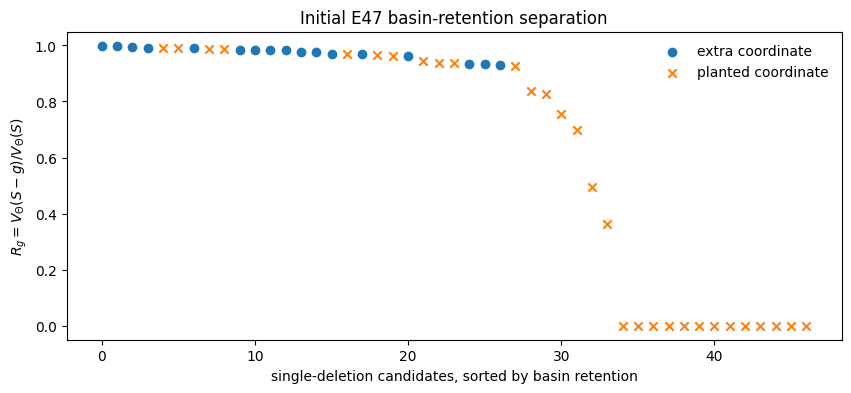

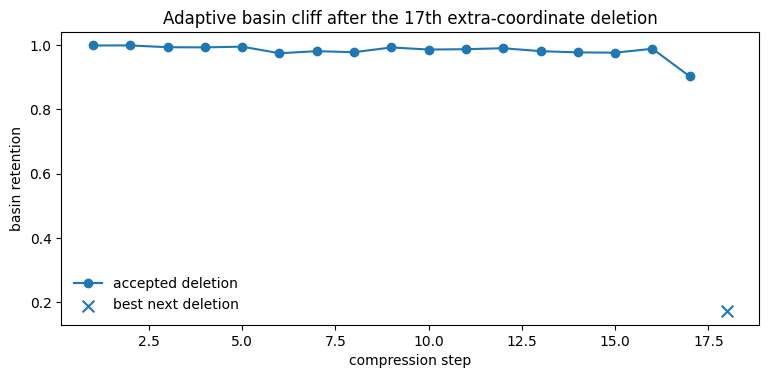

In [15]:
# ============================================================
# Cell 17 — basin-retention geometry
# ============================================================
ordered = sorted(
    INITIAL_AUDIT.deletions,
    key=lambda d: d.retention,
    reverse=True,
)
x = np.arange(len(ordered))
r = np.asarray([d.retention for d in ordered])

is_false = np.asarray([
    d.coordinate not in TRUE_SUPPORT
    for d in ordered
])

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(x[is_false], r[is_false], marker="o", label="extra coordinate")
ax.scatter(x[~is_false], r[~is_false], marker="x", label="planted coordinate")
ax.set_xlabel("single-deletion candidates, sorted by basin retention")
ax.set_ylabel(r"$R_g = V_\Theta(S-g)/V_\Theta(S)$")
ax.set_title("Initial E47 basin-retention separation")
ax.legend(frameon=False)
plt.show()

accepted_r = [step.retention for step in LINEAGE.history]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(np.arange(1, len(accepted_r) + 1), accepted_r, "o-", label="accepted deletion")
ax.scatter([len(accepted_r) + 1], [terminal_best_next], marker="x", s=70, label="best next deletion")
ax.set_xlabel("compression step")
ax.set_ylabel("basin retention")
ax.set_title("Adaptive basin cliff after the 17th extra-coordinate deletion")
ax.legend(frameon=False)
plt.show()

In [16]:
# ============================================================
# Cell 18 — new discrete description-length decomposition
# ============================================================
CONTEXT = STEP3_FACTORY_BUILDER.context

INITIAL_DL = mdld.compute_representation_description_length(
    dynamics_code_length=CONTEXT.dynamics_code_length,
    structural_blocks=CONTEXT.structural_support_blocks(frozenset(INITIAL_STATE.support)),
    support=frozenset(INITIAL_STATE.support),
    categories=INITIAL_STATE.categories,
)

TERMINAL_DL = mdld.compute_representation_description_length(
    dynamics_code_length=CONTEXT.dynamics_code_length,
    structural_blocks=CONTEXT.structural_support_blocks(frozenset(TERMINAL_STATE.support)),
    support=frozenset(TERMINAL_STATE.support),
    categories=TERMINAL_STATE.categories,
)

print("=" * 90)
print("DISCRETE REPRESENTATION DESCRIPTION LENGTH")
print("=" * 90)

for name, score in (("initial E47", INITIAL_DL), ("terminal E30", TERMINAL_DL)):
    print(f"\n{name}")
    print("  L_J / nats     :", f"{score.dynamics:.9f}")
    print("  L_S / nats     :", f"{score.structure:.9f}")
    print("  L_c / nats     :", f"{score.categories:.9f}")
    print("  L_rep / nats   :", f"{score.total:.9f}")
    print("  L_rep / bits   :", f"{score.total_bits:.9f}")
    print("  E / K          :", score.n_structural_coordinates, "/", score.n_categories)

assert np.isclose(INITIAL_DL.total, INITIAL_STATE.description_length)
assert np.isclose(TERMINAL_DL.total, TERMINAL_STATE.description_length)
assert TERMINAL_DL.total < INITIAL_DL.total

DISCRETE REPRESENTATION DESCRIPTION LENGTH

initial E47
  L_J / nats     : 0.000000000
  L_S / nats     : 87.383732851
  L_c / nats     : 136.802722637
  L_rep / nats   : 224.186455488
  L_rep / bits   : 323.432687567
  E / K          : 47 / 47

terminal E30
  L_J / nats     : 0.000000000
  L_S / nats     : 86.228459880
  L_c / nats     : 74.658236349
  L_rep / nats   : 160.886696228
  L_rep / bits   : 232.110438794
  E / K          : 30 / 30


In [17]:
# ============================================================
# Cell 19 — physical-law and amplitude validation
# ============================================================
theta_terminal = np.asarray(TERMINAL_STATE.theta, dtype=float)
alpha_terminal = float(theta_terminal[2])
alpha_taylor_cubic = float(-DIFF_SCALE**2 / 6.0)

W_REC = np.zeros((N_STAGES, M), dtype=float)

for coordinate, value in dict(TERMINAL_STATE.weights).items():
    if coordinate[0] == "baseline":
        W_REC[0, int(coordinate[1])] = float(value)

for r in range(1, N_STAGES):
    W_REC[r] = W_REC[r - 1]
    for coordinate, value in dict(TERMINAL_STATE.weights).items():
        if coordinate[0] == "transition" and int(coordinate[1]) == r - 1:
            W_REC[r, int(coordinate[2])] += float(value)

W_TRUE_GAUGE = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_GAUGE[r, EDGE_INDEX_1B[edge]] = (
            DIFF_SCALE * EDGE_WEIGHT[edge]
        )

dW_REC = np.diff(W_REC, axis=0)
dW_TRUE = np.diff(W_TRUE_GAUGE, axis=0)

active_W = W_TRUE_GAUGE != 0.0
active_dW = dW_TRUE != 0.0

W_REL_ERROR = (
    np.linalg.norm((W_REC - W_TRUE_GAUGE)[active_W])
    / np.linalg.norm(W_TRUE_GAUGE[active_W])
)
DW_REL_ERROR = (
    np.linalg.norm((dW_REC - dW_TRUE)[active_dW])
    / np.linalg.norm(dW_TRUE[active_dW])
)
INACTIVE_W_MAX = float(np.max(np.abs(W_REC[~active_W])))

print("=" * 90)
print("PHYSICAL-LAW / AMPLITUDE VALIDATION")
print("=" * 90)
print("difference scale s              :", f"{DIFF_SCALE:.12e}")
print("terminal cubic alpha            :", f"{alpha_terminal:.12e}")
print("cubic Taylor reference -s^2/6   :", f"{alpha_taylor_cubic:.12e}")
print("alpha absolute difference       :", f"{abs(alpha_terminal-alpha_taylor_cubic):.12e}")
print("W active-entry relative error   :", f"{W_REL_ERROR:.12e}")
print("Delta-W relative error          :", f"{DW_REL_ERROR:.12e}")
print("max inactive |W|                :", f"{INACTIVE_W_MAX:.12e}")

assert TERMINAL_STATE.relative_residual <= EPSILON

PHYSICAL-LAW / AMPLITUDE VALIDATION
difference scale s              : 6.728524355424e-01
terminal cubic alpha            : -7.642617154655e-02
cubic Taylor reference -s^2/6   : -7.545506666923e-02
alpha absolute difference       : 9.711048773195e-04
W active-entry relative error   : 1.028872618010e-02
Delta-W relative error          : 2.764235011403e-03
max inactive |W|                : 5.505790991106e-03


In [18]:
# ============================================================
# Cell 20 — planted-model / true-support feasibility diagnostics
# ============================================================
Y_TRUE_PLANTED = np.vstack([
    stage_field(x, int(stage))
    for x, stage in zip(
        prep.x_mid,
        prep.stage_of_observation,
    )
])

RHO_TRUE_PLANTED = (
    np.linalg.norm(prep.pairwise_target - Y_TRUE_PLANTED)
    / np.linalg.norm(prep.pairwise_target)
)

TRUE_SUPPORT_PROFILE = physprof.profile_free_weights_and_dynamics(
    CONTEXT.problem,
    frozenset(TRUE_SUPPORT),
    active_atoms=J2,
    warm_theta=theta_terminal,
    max_nfev=80,
    compute_linear_relaxation=False,
)

print("=" * 90)
print("PLANTED / TRUE-SUPPORT FEASIBILITY")
print("=" * 90)
print("exact planted sine residual     :", f"{RHO_TRUE_PLANTED:.12e}")
print("J2 true-support profiled rho    :", f"{TRUE_SUPPORT_PROFILE.fit.relative_residual:.12e}")
print("epsilon                         :", f"{EPSILON:.12e}")
print("exact planted feasible          :", RHO_TRUE_PLANTED <= EPSILON)
print("J2 true-support feasible        :", TRUE_SUPPORT_PROFILE.fit.feasible_witness)

assert RHO_TRUE_PLANTED <= EPSILON
assert TRUE_SUPPORT_PROFILE.fit.feasible_witness

PLANTED / TRUE-SUPPORT FEASIBILITY
exact planted sine residual     : 1.393383045232e-02
J2 true-support profiled rho    : 1.392683348398e-02
epsilon                         : 1.493805554839e-02
exact planted feasible          : True
J2 true-support feasible        : True


## Interpretation of this regression

This notebook establishes the code-path result we need before moving to the NetSciX abstract:

1. the same noisy trajectory and uncertainty calibration produce a non-empty observational family \(\mathcal B_\varepsilon\);
2. the new Step-3 entry point runs without the retired MDL search/precision machinery;
3. physical profiling and the new discrete representation code are used in in1;
4. the previously validated broad \(E47\) support passes directly to category-relaxed in3;
5. basin retention removes all 17 extra coordinates before the adaptive cliff;
6. the final raw support is exactly the planted \(E30\) support;
7. terminal in1 re-profiling remains inside the observational floor.

The broad-support seed and its in2 coverage certificate are frozen regression inputs here. Therefore this notebook validates the **new Step-3 framework and basin-compression stage**, not a new from-scratch broad-support discovery algorithm.

In [19]:
# ============================================================
# Cell 21 — final benchmark summary
# ============================================================
print("=" * 110)
print("06 — N=8 KURAMOTO / MEASUREMENT-NOISE / NEW STEP-3 SUMMARY")
print("=" * 110)

print("Step 1 exact transitions              :", np.array_equal(s1_check.transition_indices, true_transition_indices))
print("midpoint observations                 :", prep.n_observations)
print("noise-only epsilon                     :", f"{EPSILON_NOISE:.12e}")
print("final epsilon                          :", f"{EPSILON:.12e}")
print("Step-2 minimum residual                :", f"{FAMILY.minimum_relative_residual:.12e}")
print("Step-2 rank / nullity                  :", FAMILY.rank, "/", FAMILY.nullity)
print("Step-3 status                          :", STEP3_RESULT.status)
print("tested dynamics support                :", J2)
print("initial E / K                          :", len(INITIAL_STATE.support), "/", len(set(INITIAL_STATE.categories.values())))
print("initial physical residual              :", f"{INITIAL_STATE.relative_residual:.12e}")
print("initial basin width                    :", f"{INITIAL_AUDIT.parent_mass:.12e}")
print("initial false-vs-true deletion AUC     :", f"{AUC_FALSE_DELETION:.12f}")
print("in2 coverage status                    :", FIXED.in2.coverage_status)
print("in3 accepted deletions                 :", len(LINEAGE.history))
print("last accepted retention                :", f"{LINEAGE.history[-1].retention:.12e}")
print("best post-core retention               :", f"{terminal_best_next:.12e}")
print("in3 stop reason                        :", LINEAGE.stopped_reason)
print("final TP / FP / FN                     :", FINAL_TP, "/", FINAL_FP, "/", FINAL_FN)
print("terminal J2 residual                   :", f"{TERMINAL_STATE.relative_residual:.12e}")
print("terminal alpha                         :", f"{alpha_terminal:.12e}")
print("representation DL nats                 :", f"{INITIAL_DL.total:.6f} -> {TERMINAL_DL.total:.6f}")
print("W active-entry relative error          :", f"{W_REL_ERROR:.6e}")
print("Delta-W relative error                 :", f"{DW_REL_ERROR:.6e}")
print("Step-2+Step-3 elapsed / s              :", f"{TOTAL_STEP23_ELAPSED:.3f}")

PIPELINE_PASSED = (
    np.array_equal(s1_check.transition_indices, true_transition_indices)
    and FAMILY.minimum_relative_residual <= EPSILON
    and STEP3_RESULT.status == "outer1_complete_cross_j_selection_pending"
    and FIXED.in2.coverage_status == "coverage_saturated"
    and len(LINEAGE.history) == 17
    and LINEAGE.stopped_reason == "basin_cliff"
    and (FINAL_TP, FINAL_FP, FINAL_FN) == (30, 0, 0)
    and TERMINAL_STATE.relative_residual <= EPSILON
)

print("\nNEW STEP-3 NOISY REGRESSION PASSED     :", PIPELINE_PASSED)
print("=" * 110)

assert PIPELINE_PASSED

06 — N=8 KURAMOTO / MEASUREMENT-NOISE / NEW STEP-3 SUMMARY
Step 1 exact transitions              : True
midpoint observations                 : 708
noise-only epsilon                     : 1.443805554839e-02
final epsilon                          : 1.493805554839e-02
Step-2 minimum residual                : 8.787167486376e-03
Step-2 rank / nullity                  : 1788 / 60
Step-3 status                          : outer1_complete_cross_j_selection_pending
tested dynamics support                : (0, 2)
initial E / K                          : 47 / 47
initial physical residual              : 1.392326552914e-02
initial basin width                    : 2.608764447575e-01
initial false-vs-true deletion AUC     : 0.858823529412
in2 coverage status                    : coverage_saturated
in3 accepted deletions                 : 17
last accepted retention                : 9.024361556159e-01
best post-core retention               : 1.709249548435e-01
in3 stop reason                        : 